# 25. Stage 1 Rescoring Rule v2

## 이 Notebook이 답하는 질문 하나

**Stage 1의 `avoid` micro-F1 0.000과 `additional` 0.118 중 얼마가 채점 규칙의 문제이고, 얼마가 모델의 문제인가?**

Gold는 Query 원문에서 잘라낸 한국어 span(`머스크`, `깔끔한`)이고 Prediction은 프롬프트 지시에 따른 영어 canonical 표기(`musk`)와 확장된 구(`깔끔한 향`)다.
현재 채점은 `frozenset` 완전 일치라 교집합이 비어 있다. 이 Notebook은 채점 규칙을 층으로 분해해 각 층의 기여를 측정한다.

## 0. 실행 조건

**하지 않는 것**

- Golden Set(`13_stage1_golden_set_v1_200.xlsx`) 수정 — `GOLD_ERROR`도 별도 보고서로만 남긴다
- Notebook 13/14/15/16 및 그 산출물 수정 — 15·16의 SHA-256 guard가 걸려 있다
- Stage 1 Prompt 변경, 모델 재실행, **API 호출 없음**
- `data/scent_knowledge/` 아래 파일 생성 — 평가에서 유래한 별칭표는 `analysis_outputs/`에 둔다

**보장하는 것**

- 모든 층을 끄면 기존 published 지표를 오차 `1e-9` 이내로 재현한다. 실패하면 `raise`한다
- 출력은 `analysis_outputs/25_*` 5개뿐이다
- `evaluation_data/`와 `data/`는 실행 전후 디렉터리 해시가 동일해야 한다

In [1]:
import collections
import hashlib
import itertools
import json
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

RULE_VERSION = "stage1_rescore_v2"

# True로 두면 계산과 표시만 하고 파일을 만들지 않는다.
REPORT_ONLY = False

print("RULE_VERSION:", RULE_VERSION)
print("REPORT_ONLY:", REPORT_ONLY)

RULE_VERSION: stage1_rescore_v2
REPORT_ONLY: False


## 1. 경로 · 입력 해싱 · 쓰기 가드

입력은 실행 전후로 SHA-256을 대조한다. `evaluation_data/`와 `data/`는 디렉터리 전체를 지문화해
`write_output()`을 우회한 실수까지 잡는다.

In [2]:
PROJECT_ROOT = pathlib.Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
GOLDSET_PATH = PROJECT_ROOT / "evaluation_data" / "stage1" / "13_stage1_golden_set_v1_200.xlsx"

INPUT_PATHS = {
    "goldset": GOLDSET_PATH,
    "pred_rule": OUTPUT_DIR / "13_rule_stage1_predictions.csv",
    "pred_extended_rule": OUTPUT_DIR / "14_extended_rule_stage1_predictions.csv",
    "pred_llm": OUTPUT_DIR / "15_llm_stage1_predictions.csv",
    "metrics_rule": OUTPUT_DIR / "13_rule_stage1_metrics.csv",
    "metrics_extended_rule": OUTPUT_DIR / "14_extended_rule_stage1_metrics.csv",
    "metrics_llm": OUTPUT_DIR / "15_llm_stage1_metrics.csv",
    "rule_lexicon": OUTPUT_DIR / "11_rule_lexicon.csv",
    "vocab_note": OUTPUT_DIR / "17_fragrantica_note_vocabulary.csv",
    "vocab_accord": OUTPUT_DIR / "17_fragrantica_accord_vocabulary.csv",
}

OUTPUT_PATHS = {
    "metrics": OUTPUT_DIR / "25_stage1_rescoring_metrics.csv",
    "layers": OUTPUT_DIR / "25_stage1_rescoring_layer_contribution.csv",
    "detail": OUTPUT_DIR / "25_stage1_rescoring_match_detail.csv",
    "alias": OUTPUT_DIR / "25_stage1_scoring_alias_v1.csv",
    "summary": OUTPUT_DIR / "25_stage1_rescoring_summary.md",
}


def sha256_file(path):
    digest = hashlib.sha256()
    with pathlib.Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def directory_fingerprint(root):
    root = pathlib.Path(root)
    if not root.is_dir():
        return {}
    return {
        path.relative_to(PROJECT_ROOT).as_posix(): sha256_file(path)
        for path in sorted(root.rglob("*"))
        if path.is_file()
    }


missing = [str(path) for path in INPUT_PATHS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f"필수 입력이 없습니다: {missing}")

input_hashes_before = {label: sha256_file(path) for label, path in INPUT_PATHS.items()}
FROZEN_DIRS = [PROJECT_ROOT / "evaluation_data", PROJECT_ROOT / "data"]
frozen_before = {str(root): directory_fingerprint(root) for root in FROZEN_DIRS}

# 덮어쓰면 안 되는 기존 산출물
FROZEN_FILES = {path.resolve() for path in INPUT_PATHS.values()} | {
    (OUTPUT_DIR / name).resolve()
    for name in [
        "13_rule_stage1_evaluation.csv",
        "14_extended_rule_stage1_evaluation.csv",
        "14_rule_comparison.csv",
        "15_llm_stage1_evaluation.csv",
        "15_llm_stage1_errors.csv",
        "15_llm_vs_extended_query_changes.csv",
        "16_golden_set_quality_audit_candidates.csv",
    ]
}


def write_output(path, writer):
    """analysis_outputs/ 직속 · 25_ prefix · 보호 파일 아님 — 셋을 모두 만족할 때만 쓴다."""
    path = pathlib.Path(path).resolve()
    if path.parent != OUTPUT_DIR.resolve():
        raise RuntimeError(f"쓰기 허용 디렉터리가 아닙니다: {path}")
    if not path.name.startswith("25_"):
        raise RuntimeError(f"25_ prefix가 아닌 출력은 금지합니다: {path.name}")
    if path in FROZEN_FILES:
        raise RuntimeError(f"보호 파일 덮어쓰기 시도: {path.name}")
    if REPORT_ONLY:
        print(f"[REPORT_ONLY] 저장 생략: {path.name}")
        return None
    writer(path)
    print(f"저장: {path.name}")
    return path


display(pd.Series(input_hashes_before, name="sha256").str.slice(0, 16).to_frame())
print("frozen dir files:", {k: len(v) for k, v in frozen_before.items()})

,sha256
goldset,a56613ad4bb082d2
pred_rule,fee5a8b53a3b9094
pred_extended_rule,c5edafa792b8ce74
pred_llm,f36e7266f2319be3
metrics_rule,9be6362c31aade22
metrics_extended_rule,4bf0f63b4c957391
metrics_llm,9000e8e5de542cb6
rule_lexicon,ab425963f6b0c2b8
vocab_note,3b3c340c4da9eab9
vocab_accord,9e5605fc54f68549


frozen dir files: {'C:\\Users\\SSAFY\\Desktop\\hyanghae\\EDA\\evaluation_data': 6, 'C:\\Users\\SSAFY\\Desktop\\hyanghae\\EDA\\data': 17}


## 2. 채점 규칙 정의 — Prediction을 읽기 전에 고정한다

14번의 관례를 따라 데이터를 보기 전에 규칙을 동결한다. 층은 각각 독립적으로 켜고 끌 수 있어야 한다.
"규칙을 바꿨더니 0.000이 0.49가 됐다"가 아니라 **"어느 층이 얼마를 기여했다"** 를 답하는 것이 이 Notebook의 산출물이기 때문이다.

| 층 | 하는 일 |
|---|---|
| `L0` | NFKC + casefold + 공백 정리 (항상 적용, 대조군) |
| `L1_punct` | 한글·영숫자·공백 외 문자를 공백으로 치환 |
| `L2_alias` | 한↔영 별칭을 canonical key로 치환 |
| `L3_suffix` | `향/향기/향수/냄새/노트/계열/느낌/것/거/건` 접미사 제거 후 별칭 재조회 |
| `L4_contain` | 포함 관계 허용. 긴 쪽의 초과 어절이 `MAX_EXCESS_TOKENS` 이하일 때만 |

`MAX_EXCESS_TOKENS = 1`은 사전 등록한 값이다. `무제한`은 Extended Rule의 과포획 span까지 득점시키므로 채택하지 않는다.

In [3]:
MAX_EXCESS_TOKENS = 1
MIN_MATCH_CHARS = 2

ALL_LAYERS = ["L1_punct", "L2_alias", "L3_suffix", "L4_contain"]
LAYERS_OFF = {name: False for name in ALL_LAYERS}
LAYERS_FULL = {name: True for name in ALL_LAYERS}

PUNCT_PATTERN = re.compile(r"[^0-9a-z\uac00-\ud7a3\s]+")
COMPACT_PATTERN = re.compile(r"[^0-9a-z\uac00-\ud7a3]+")
SUFFIX_PATTERN = re.compile(r"\s*(?:향기|향수|향|냄새|노트|계열|느낌|것|거|건)$")


def normalize_l0(value):
    """13번 cell 8의 프로젝트 표준 정규화."""
    text = unicodedata.normalize("NFKC", "" if value is None else str(value)).casefold()
    return re.sub(r"\s+", " ", text).strip()


def strip_punct(key):
    return re.sub(r"\s+", " ", PUNCT_PATTERN.sub(" ", key)).strip()


def strip_scent_suffix(key):
    """의미가 비어 있는 후행 명사를 제거한다. 2자 미만이 되면 중단."""
    current = key
    for _ in range(3):
        stripped = SUFFIX_PATTERN.sub("", current).strip()
        if stripped == current or len(stripped.replace(" ", "")) < MIN_MATCH_CHARS:
            break
        current = stripped
    return current


def canonical_key(value, layers, alias):
    key = normalize_l0(value)
    if layers.get("L1_punct"):
        key = strip_punct(key)
    if layers.get("L2_alias"):
        key = alias.get(key, key)
    if layers.get("L3_suffix"):
        stripped = strip_scent_suffix(key)
        if stripped != key:
            key = alias.get(stripped, stripped) if layers.get("L2_alias") else stripped
    return key


def dedupe_keys(keys):
    seen, ordered = set(), []
    for key in keys:
        if key and key not in seen:
            seen.add(key)
            ordered.append(key)
    return ordered


def pair_quality(gold_key, pred_key, layers, max_excess=None):
    """None이면 불일치. tier 2 = canonical 완전 일치, tier 1 = 포함."""
    if gold_key == pred_key:
        return (2, 1.0)
    if not layers.get("L4_contain"):
        return None
    budget = MAX_EXCESS_TOKENS if max_excess is None else max_excess
    gold_compact = COMPACT_PATTERN.sub("", gold_key)
    pred_compact = COMPACT_PATTERN.sub("", pred_key)
    if not gold_compact or not pred_compact:
        return None
    if len(gold_compact) <= len(pred_compact):
        short_key, long_key, short_c, long_c = gold_key, pred_key, gold_compact, pred_compact
    else:
        short_key, long_key, short_c, long_c = pred_key, gold_key, pred_compact, gold_compact
    if len(short_c) < MIN_MATCH_CHARS or short_c not in long_c:
        return None
    excess = len(long_key.split()) - len(short_key.split())
    if excess > budget:
        return None
    return (1, 1.0 / (1 + max(excess, 0)))


def match_items(gold_items, pred_items, layers, alias, max_excess=None):
    """greedy 1:1 매칭. 정렬 tiebreak을 key 문자열로 두어 입력 순서에 의존하지 않는다."""
    gold_keys = dedupe_keys([canonical_key(v, layers, alias) for v in gold_items])
    pred_keys = dedupe_keys([canonical_key(v, layers, alias) for v in pred_items])

    candidates = []
    for gold_index, gold_key in enumerate(gold_keys):
        for pred_index, pred_key in enumerate(pred_keys):
            quality = pair_quality(gold_key, pred_key, layers, max_excess)
            if quality is not None:
                tier, score = quality
                candidates.append((-tier, -score, gold_key, pred_key, gold_index, pred_index))
    candidates.sort()

    used_gold, used_pred, pairs = set(), set(), []
    for neg_tier, neg_score, _, _, gold_index, pred_index in candidates:
        if gold_index in used_gold or pred_index in used_pred:
            continue
        used_gold.add(gold_index)
        used_pred.add(pred_index)
        pairs.append((gold_index, pred_index, -neg_tier, -neg_score))

    tp = len(pairs)
    return tp, len(pred_keys) - tp, len(gold_keys) - tp, pairs, gold_keys, pred_keys


def max_cardinality(gold_keys, pred_keys, layers, max_excess=None):
    """브루트포스 최대 매칭. greedy가 최적인지 검증하는 용도 (항목 수가 작을 때만)."""
    adjacency = {
        (gi, pi)
        for gi, gk in enumerate(gold_keys)
        for pi, pk in enumerate(pred_keys)
        if pair_quality(gk, pk, layers, max_excess) is not None
    }
    if not adjacency:
        return 0
    for size in range(min(len(gold_keys), len(pred_keys)), 0, -1):
        for gold_subset in itertools.combinations(range(len(gold_keys)), size):
            for pred_perm in itertools.permutations(range(len(pred_keys)), size):
                if all((gold_subset[i], pred_perm[i]) in adjacency for i in range(size)):
                    return size
    return 0


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def evaluate_multilabel(gold_values, pred_values, layers, alias, mask=None, max_excess=None):
    """반환 키는 13번 cell 16과 동일하게 유지한다."""
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    tp = fp = fn = eligible = 0
    for gold, pred, include in zip(gold_values, pred_values, mask):
        if not include:
            continue
        eligible += 1
        item_tp, item_fp, item_fn, _, _, _ = match_items(gold, pred, layers, alias, max_excess)
        tp += item_tp
        fp += item_fp
        fn += item_fn
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    return {
        "precision": precision,
        "recall": recall,
        "f1": safe_divide(2 * precision * recall, precision + recall),
        "tp": tp, "fp": fp, "fn": fn, "eligible_queries": eligible,
    }


def evaluate_coverage(gold_values, pred_values, layers, alias, mask=None, max_excess=None):
    """1:1 상한 참고용. 하나의 prediction이 여러 gold를 덮는 것을 허용한다."""
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    gold_hit = gold_total = pred_hit = pred_total = 0
    for gold, pred, include in zip(gold_values, pred_values, mask):
        if not include:
            continue
        gold_keys = dedupe_keys([canonical_key(v, layers, alias) for v in gold])
        pred_keys = dedupe_keys([canonical_key(v, layers, alias) for v in pred])
        gold_total += len(gold_keys)
        pred_total += len(pred_keys)
        gold_hit += sum(
            1 for gk in gold_keys
            if any(pair_quality(gk, pk, layers, max_excess) for pk in pred_keys)
        )
        pred_hit += sum(
            1 for pk in pred_keys
            if any(pair_quality(gk, pk, layers, max_excess) for gk in gold_keys)
        )
    precision = safe_divide(pred_hit, pred_total)
    recall = safe_divide(gold_hit, gold_total)
    return {
        "precision": precision, "recall": recall,
        "f1": safe_divide(2 * precision * recall, precision + recall),
    }


def list_exact(gold_items, pred_items, layers, alias):
    _, fp, fn, _, _, _ = match_items(gold_items, pred_items, layers, alias)
    return fp == 0 and fn == 0


def normalize_scalar(value, layers, alias):
    return canonical_key(value, layers, alias)


def scalar_accuracy(gold_values, pred_values, layers, alias, mask=None):
    if mask is None:
        mask = np.ones(len(gold_values), dtype=bool)
    compared = [
        normalize_scalar(gold, layers, alias) == normalize_scalar(pred, layers, alias)
        for gold, pred, include in zip(gold_values, pred_values, mask)
        if include
    ]
    return {
        "accuracy": float(np.mean(compared)) if compared else np.nan,
        "eligible_queries": len(compared),
    }


def context_exact(gold, pred, layers, alias):
    return all(list_exact(gold[k], pred[k], layers, alias) for k in ["season", "daypart", "gender"])


def performance_exact(gold, pred, layers, alias):
    return all(
        normalize_scalar(gold[k], layers, alias) == normalize_scalar(pred[k], layers, alias)
        for k in ["intensity", "longevity"]
    )


def json_text(value):
    return json.dumps(value, ensure_ascii=False, separators=(",", ":"))


display(pd.DataFrame([
    {"layer": "L0", "always_on": True, "does": "NFKC + casefold + 공백 정리"},
    {"layer": "L1_punct", "always_on": False, "does": "구두점을 공백으로"},
    {"layer": "L2_alias", "always_on": False, "does": "한↔영 별칭 → canonical key"},
    {"layer": "L3_suffix", "always_on": False, "does": "향/냄새/노트/계열/느낌 접미사 제거"},
    {"layer": "L4_contain", "always_on": False, "does": f"포함 관계, 초과 어절 <= {MAX_EXCESS_TOKENS}"},
]))

,layer,always_on,does
0,L0,True,NFKC + casefold + 공백 정리
1,L1_punct,False,구두점을 공백으로
2,L2_alias,False,한↔영 별칭 → canonical key
3,L3_suffix,False,향/냄새/노트/계열/느낌 접미사 제거
4,L4_contain,False,"포함 관계, 초과 어절 <= 1"


## 3. 채점용 별칭표 — 근거 tier를 분리해 기록한다

`data/scent_knowledge/`가 아니라 `analysis_outputs/`에 둔다. 이 표의 행들은 Golden Set 200개를 보고 고른 것이라,
런타임 Lexicon이 살 디렉터리에 두면 언젠가 Parser가 로드해 Stage 1 평가가 순환 참조가 된다.

`SENSORY` tier는 Fragrantica 어휘로 검증할 수 없는 유일한 층이므로 기여도를 별도 행으로 보고한다.

**넣지 않는 것** — 번역 판단이지 표기 정규화가 아니다. 사람 판정으로 보낸다.
`아저씨 같은 느낌 / 세제 냄새 / 절 냄새 / 조말론 블랙베리 / 너무 음식같은 느낌`

In [4]:
lexicon_df = pd.read_csv(INPUT_PATHS["rule_lexicon"])
hangul_rows = lexicon_df[lexicon_df["surface_form"].astype(str).str.contains(r"[\uac00-\ud7a3]")]

alias_rows = []


def add_alias(entry_id, expression, aliases, canonical, tier, evidence, scope_note, expression_type):
    alias_rows.append({
        "entry_id": entry_id,
        "expression": expression,
        "aliases": "|".join(aliases),
        "canonical_key": canonical,
        "expression_type": expression_type,
        "target_field": "STAGE1_DIRECT",
        "evidence_tier": tier,
        "evidence": evidence,
        "scope_note": scope_note,
        "status": "active",
    })


# tier 1: 11번 Rule Lexicon의 Hangul 행 (기계 추출)
for row in hangul_rows.itertuples(index=False):
    add_alias(
        f"kr.lex11.{normalize_l0(row.feature_name).replace(' ', '_')}",
        row.surface_form, [row.surface_form], normalize_l0(row.feature_name),
        "LEXICON_11", "analysis_outputs/11_rule_lexicon.csv",
        f"{row.mapping_type} / {row.feature_type}",
        "DIRECT_SCENT" if row.feature_type == "ACCORD" else "CONTEXT",
    )

# tier 2: 14번 DIRECT_SCENT_RULES (기계 추출)
for surface, feature in [("바닐라", "Vanilla"), ("장미", "Rose"), ("민트", "Mint"), ("레몬", "Lemon")]:
    add_alias(
        f"kr.lex14.{normalize_l0(feature)}", surface, [surface], normalize_l0(feature),
        "LEXICON_14", "14_stage1_extended_rule_evaluation.ipynb DIRECT_SCENT_RULES",
        "Note 직접 언급", "DIRECT_SCENT",
    )

# tier 3: 외래어 음차 (영어측이 Fragrantica 어휘에 존재해야 통과)
for surface_list, feature in [
    (["머스크", "머스키"], "Musk"), (["패출리", "파출리"], "Patchouli"),
    (["인센스"], "Incense"), (["초코", "초콜릿"], "Chocolate"),
    (["바질"], "Basil"), (["체리"], "Cherry"),
    (["코코넛"], "Coconut"), (["라벤더"], "Lavender"),
    (["베르가못", "버가못"], "Bergamot"), (["샌달우드", "샌들우드"], "Sandalwood"),
]:
    add_alias(
        f"kr.loan.{normalize_l0(feature)}", surface_list[0], surface_list, normalize_l0(feature),
        "LOANWORD", "한국어 음차 표기", "외래어 표기 변형", "DIRECT_SCENT",
    )

# tier 4: 고유어 명사 번역
for surface_list, feature in [
    (["복숭아"], "Peach"), (["장미"], "Rose"), (["레몬"], "Lemon"),
    (["자몽"], "Grapefruit"), (["백단"], "Sandalwood"),
]:
    add_alias(
        f"kr.trans.{normalize_l0(feature)}", surface_list[0], surface_list, normalize_l0(feature),
        "TRANSLATION", "고유어 명사 대응", "향료 이름 번역", "DIRECT_SCENT",
    )

# tier 5: 감각 형용사 — Fragrantica 어휘로 검증 불가. 기여도를 별도 보고한다.
for surface_list, canonical in [
    (["달콤한", "달달한", "달달", "단", "달콤"], "sweet"),
    (["무거운", "무겁거나", "무거움", "묵직한"], "heavy"),
    (["가벼운", "가볍고", "가벼움"], "light"),
    (["시원한", "시원하고", "청량한"], "fresh"),
    (["강한", "진한", "센"], "strong"),
]:
    add_alias(
        f"kr.sens.{canonical}", surface_list[0], surface_list, canonical,
        "SENSORY", "감각 형용사 대응 (외부 어휘 검증 불가)", "형용사 tier", "SENSORY",
    )

alias_table_df = pd.DataFrame(alias_rows)

# --- 검증 1: 하나의 표면형이 서로 다른 canonical key로 가지 않는가
surface_map = {}
conflicts = []
for row in alias_table_df.itertuples(index=False):
    for surface in row.aliases.split("|"):
        key = normalize_l0(surface)
        if key in surface_map and surface_map[key] != row.canonical_key:
            conflicts.append((surface, surface_map[key], row.canonical_key))
        surface_map[key] = row.canonical_key
if conflicts:
    raise ValueError(f"표면형이 서로 다른 canonical key로 매핑됩니다: {conflicts}")

# --- 검증 2: LOANWORD / TRANSLATION의 영어측이 Fragrantica 어휘에 존재하는가
note_vocab = {normalize_l0(v) for v in pd.read_csv(INPUT_PATHS["vocab_note"]).iloc[:, 0]}
accord_vocab = {normalize_l0(v) for v in pd.read_csv(INPUT_PATHS["vocab_accord"]).iloc[:, 0]}
known_vocab = note_vocab | accord_vocab
unverified = [
    (row.entry_id, row.canonical_key)
    for row in alias_table_df.itertuples(index=False)
    if row.evidence_tier in {"LOANWORD", "TRANSLATION"} and row.canonical_key not in known_vocab
]
if unverified:
    raise ValueError(f"Fragrantica 어휘에 없는 영어측 canonical key: {unverified}")

# --- canonical key로 가는 최종 dict (영어측 자기 자신도 포함)
ALIAS = dict(surface_map)
for canonical in alias_table_df["canonical_key"].unique():
    ALIAS.setdefault(canonical, canonical)

ALIAS_BY_TIER = {}
for tier in alias_table_df["evidence_tier"].unique():
    tier_rows = alias_table_df[alias_table_df["evidence_tier"] == tier]
    mapping = {}
    for row in tier_rows.itertuples(index=False):
        for surface in row.aliases.split("|"):
            mapping[normalize_l0(surface)] = row.canonical_key
        mapping.setdefault(row.canonical_key, row.canonical_key)
    ALIAS_BY_TIER[tier] = mapping

print(f"별칭 항목 {len(alias_table_df)}개 / 표면형 {len(ALIAS)}개")
display(alias_table_df.groupby("evidence_tier").size().to_frame("entries"))
display(alias_table_df[["entry_id", "expression", "aliases", "canonical_key", "evidence_tier"]])

별칭 항목 40개 / 표면형 89개


,entries
evidence_tier,
LEXICON_11,16
LEXICON_14,4
LOANWORD,10
SENSORY,5
TRANSLATION,5


,entry_id,expression,aliases,canonical_key,evidence_tier
0,kr.lex11.autumn,가을,가을,autumn,LEXICON_11
1,kr.lex11.winter,겨울,겨울,winter,LEXICON_11
2,kr.lex11.day,낮,낮,day,LEXICON_11
3,kr.lex11.vanilla,바닐라,바닐라,vanilla,LEXICON_11
4,kr.lex11.night,밤,밤,night,LEXICON_11
5,kr.lex11.spring,봄,봄,spring,LEXICON_11
6,kr.lex11.sweet,스위트,스위트,sweet,LEXICON_11
7,kr.lex11.citrus,시트러스,시트러스,citrus,LEXICON_11
8,kr.lex11.aromatic,아로마틱,아로마틱,aromatic,LEXICON_11
9,kr.lex11.amber,앰버,앰버,amber,LEXICON_11


## 4. Golden Set 로드 (읽기 전용)

13번 cell 6의 loader/validator를 그대로 쓴다. 더해서 24번 cell 3의 불변식을 재확인한다 —
`gold_avoid`와 `gold_additional_requirements`의 모든 항목은 `query_text`의 부분 문자열이어야 한다.

In [5]:
JSON_COLUMNS = [
    "gold_scent_preference", "gold_context", "gold_performance",
    "gold_avoid", "gold_additional_requirements",
]
EXPECTED_COLUMNS = ["query_id", "query_text", *JSON_COLUMNS]


def load_goldset(path=GOLDSET_PATH):
    return pd.read_excel(path, sheet_name="Golden Set", header=4, dtype=str, keep_default_na=False)


def validate_goldset(frame):
    if frame.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(f"Golden Set 컬럼 불일치: {frame.columns.tolist()}")
    if len(frame) != 200:
        raise ValueError(f"Golden Set은 200개여야 합니다: {len(frame)}")
    if frame["query_id"].duplicated().any() or frame["query_text"].duplicated().any():
        raise ValueError("Golden Set query_id/query_text 중복")
    parsed = frame.copy()
    for column in JSON_COLUMNS:
        parsed[column] = frame[column].map(json.loads)
    return parsed


gold_df = validate_goldset(load_goldset())

# 24번 cell 3의 불변식 재확인
span_violations = [
    (row.query_id, field, item)
    for row in gold_df.itertuples(index=False)
    for field in ["gold_avoid", "gold_additional_requirements"]
    for item in getattr(row, field)
    if item.strip() and item.strip() not in row.query_text
]
if span_violations:
    raise ValueError(f"원문에 없는 annotation: {span_violations[:5]}")

gold_presence = pd.Series({
    "scent_preference": int(gold_df["gold_scent_preference"].map(bool).sum()),
    "context": int(gold_df["gold_context"].map(lambda x: any(map(bool, x.values()))).sum()),
    "performance": int(gold_df["gold_performance"].map(lambda x: any(map(bool, x.values()))).sum()),
    "avoid": int(gold_df["gold_avoid"].map(bool).sum()),
    "additional_requirements": int(gold_df["gold_additional_requirements"].map(bool).sum()),
}, name="gold_nonempty_query_count")

print(f"Golden Set {len(gold_df)}개 / substring 불변식 통과")
display(gold_presence.to_frame())

Golden Set 200개 / substring 불변식 통과


,gold_nonempty_query_count
scent_preference,39
context,43
performance,17
avoid,36
additional_requirements,170


## 5. Prediction 3종 로드 — API 호출 없음

세 파일 모두 `pred_*` 5개 컬럼을 JSON 문자열로 갖고 있다. 15번의 checkpoint는 필요하지 않다.

In [6]:
PRED_COLUMNS = [
    "pred_scent_preference", "pred_context", "pred_performance",
    "pred_avoid", "pred_additional_requirements",
]
SYSTEMS = ["rule", "extended_rule", "llm"]

merged = {}
for system in SYSTEMS:
    frame = pd.read_csv(INPUT_PATHS[f"pred_{system}"], dtype={"query_id": str}, keep_default_na=False)
    if len(frame) != 200:
        raise ValueError(f"{system}: 200행이어야 합니다 ({len(frame)})")
    for column in PRED_COLUMNS:
        frame[column] = frame[column].map(json.loads)
    merged_df = gold_df.merge(frame[["query_id", *PRED_COLUMNS]], on="query_id", how="inner", validate="1:1")
    if len(merged_df) != 200:
        raise ValueError(f"{system}: query_id 정렬 실패 ({len(merged_df)})")
    merged[system] = merged_df

# 브루트포스 최적성 검증이 현실적인 범위인지 확인
max_items = max(
    max(len(getattr(row, column)) for column in ["gold_avoid", "gold_additional_requirements"])
    for row in gold_df.itertuples(index=False)
)
max_pred_items = max(
    max(len(getattr(row, column)) for column in ["pred_avoid", "pred_additional_requirements"])
    for system in SYSTEMS for row in merged[system].itertuples(index=False)
)
if max(max_items, max_pred_items) > 8:
    raise ValueError("항목 수가 8을 넘어 브루트포스 검증이 비현실적입니다.")

print(f"gold 최대 항목 수 {max_items} / pred 최대 항목 수 {max_pred_items}")
display(pd.DataFrame([
    {
        "system": system,
        "avoid 비어있음": int(merged[system]["pred_avoid"].map(lambda x: not x).sum()),
        "additional 비어있음": int(merged[system]["pred_additional_requirements"].map(lambda x: not x).sum()),
    }
    for system in SYSTEMS
]))

gold 최대 항목 수 4 / pred 최대 항목 수 4


,system,avoid 비어있음,additional 비어있음
0,rule,200,200
1,extended_rule,179,200
2,llm,173,15


## 6. 정규화기 대조 — 15번의 NFKC 누락

13/14번은 `unicodedata.normalize("NFKC", ...)`를 적용하고 15번은 하지 않는다. 통일하기 전에
**실제로 차이를 만드는 문자열이 몇 개인지 먼저 센다.** 0이면 통일이 안전하다는 증명이 되고,
0이 아니면 그 차이가 채점 변경 안에 숨지 않는다.

In [7]:
def nb15_normalize_text(value):
    """15번 cell 35 원문."""
    if value is None:
        return ""
    return re.sub(r"\s+", " ", str(value).strip()).casefold()


label_strings = set()
for row in gold_df.itertuples(index=False):
    label_strings.update(row.gold_scent_preference)
    label_strings.update(row.gold_avoid)
    label_strings.update(row.gold_additional_requirements)
    for key in ["season", "daypart", "gender"]:
        label_strings.update(row.gold_context[key])
for system in SYSTEMS:
    for row in merged[system].itertuples(index=False):
        label_strings.update(row.pred_scent_preference)
        label_strings.update(row.pred_avoid)
        label_strings.update(row.pred_additional_requirements)
        for key in ["season", "daypart", "gender"]:
            label_strings.update(row.pred_context[key])

divergent = sorted(s for s in label_strings if normalize_l0(s) != nb15_normalize_text(s))
normalizer_divergent_strings = len(divergent)

print(f"검사한 문자열 {len(label_strings)}개 / NFKC 차이 {normalizer_divergent_strings}개")
if divergent:
    display(pd.DataFrame({"raw": divergent[:50]}))
else:
    print("차이가 없으므로 13번 표준 정규화로 통일한다.")

검사한 문자열 639개 / NFKC 차이 0개
차이가 없으므로 13번 표준 정규화로 통일한다.


## 7. 재현 게이트 — 모든 층을 끄면 기존 수치가 나와야 한다

이 게이트가 통과해야 새 채점기가 "다시 구현한 것"이 아니라 **"기존 채점기 + 토글"** 임이 증명된다.
실패하면 이후 결과는 신뢰할 수 없으므로 즉시 중단한다.

In [8]:
FIELD_ORDER = ["scent", "context", "performance", "avoid", "additional"]


def score_system(system, layers, alias, max_excess=None):
    frame = merged[system]
    multilabel_fields = {
        "scent": (frame.gold_scent_preference.tolist(), frame.pred_scent_preference.tolist()),
        "season": ([x["season"] for x in frame.gold_context], [x["season"] for x in frame.pred_context]),
        "daypart": ([x["daypart"] for x in frame.gold_context], [x["daypart"] for x in frame.pred_context]),
        "gender": ([x["gender"] for x in frame.gold_context], [x["gender"] for x in frame.pred_context]),
        "avoid": (frame.gold_avoid.tolist(), frame.pred_avoid.tolist()),
        "additional": (frame.gold_additional_requirements.tolist(), frame.pred_additional_requirements.tolist()),
    }
    all_metrics, positive_metrics = {}, {}
    for field, (gold_values, pred_values) in multilabel_fields.items():
        all_metrics[field] = evaluate_multilabel(gold_values, pred_values, layers, alias, None, max_excess)
        positive_mask = np.asarray([
            bool(dedupe_keys([canonical_key(v, layers, alias) for v in value])) for value in gold_values
        ])
        positive_metrics[field] = evaluate_multilabel(
            gold_values, pred_values, layers, alias, positive_mask, max_excess
        )

    intensity_gold = [x["intensity"] for x in frame.gold_performance]
    intensity_pred = [x["intensity"] for x in frame.pred_performance]
    longevity_gold = [x["longevity"] for x in frame.gold_performance]
    longevity_pred = [x["longevity"] for x in frame.pred_performance]
    scalar_metrics = {
        "intensity": scalar_accuracy(intensity_gold, intensity_pred, layers, alias),
        "longevity": scalar_accuracy(longevity_gold, longevity_pred, layers, alias),
    }
    positive_scalar = {
        "intensity": scalar_accuracy(intensity_gold, intensity_pred, layers, alias,
                                     np.asarray([bool(normalize_scalar(x, layers, alias)) for x in intensity_gold])),
        "longevity": scalar_accuracy(longevity_gold, longevity_pred, layers, alias,
                                     np.asarray([bool(normalize_scalar(x, layers, alias)) for x in longevity_gold])),
    }

    matches_per_query = []
    for row in frame.itertuples(index=False):
        matches_per_query.append({
            "scent": list_exact(row.gold_scent_preference, row.pred_scent_preference, layers, alias),
            "context": context_exact(row.gold_context, row.pred_context, layers, alias),
            "performance": performance_exact(row.gold_performance, row.pred_performance, layers, alias),
            "avoid": list_exact(row.gold_avoid, row.pred_avoid, layers, alias),
            "additional": list_exact(row.gold_additional_requirements, row.pred_additional_requirements, layers, alias),
        })
    field_exact_rates = pd.Series({
        field: float(np.mean([m[field] for m in matches_per_query])) for field in FIELD_ORDER
    })
    subfield_exact_rates = pd.Series({
        "context_season": float(np.mean([
            list_exact(g["season"], p["season"], layers, alias)
            for g, p in zip(frame.gold_context, frame.pred_context)])),
        "context_daypart": float(np.mean([
            list_exact(g["daypart"], p["daypart"], layers, alias)
            for g, p in zip(frame.gold_context, frame.pred_context)])),
        "context_gender": float(np.mean([
            list_exact(g["gender"], p["gender"], layers, alias)
            for g, p in zip(frame.gold_context, frame.pred_context)])),
        "performance_intensity": float(np.mean([
            normalize_scalar(g["intensity"], layers, alias) == normalize_scalar(p["intensity"], layers, alias)
            for g, p in zip(frame.gold_performance, frame.pred_performance)])),
        "performance_longevity": float(np.mean([
            normalize_scalar(g["longevity"], layers, alias) == normalize_scalar(p["longevity"], layers, alias)
            for g, p in zip(frame.gold_performance, frame.pred_performance)])),
    })
    exact_match_flags = [all(m.values()) for m in matches_per_query]

    return {
        "all": all_metrics, "positive": positive_metrics,
        "scalar": scalar_metrics, "positive_scalar": positive_scalar,
        "field_exact": field_exact_rates, "subfield_exact": subfield_exact_rates,
        "exact_flags": exact_match_flags,
        "exact_match_count": int(sum(exact_match_flags)),
        "exact_match_rate": float(np.mean(exact_match_flags)),
        "matches_per_query": matches_per_query,
    }


def metric_dict(result):
    out = {
        "exact_match_count": result["exact_match_count"],
        "exact_match_rate": result["exact_match_rate"],
        "overall_exact_match": result["exact_match_rate"],
    }
    for field, value in result["field_exact"].items():
        out[f"{field}_exact_match"] = value
    for field, value in result["subfield_exact"].items():
        out[f"{field}_exact_match"] = value
    for field, values in result["all"].items():
        for metric in ["precision", "recall", "f1"]:
            out[f"{field}_micro_{metric}"] = values[metric]
    for field, values in result["scalar"].items():
        if not pd.isna(values["accuracy"]):
            out[f"{field}_accuracy"] = values["accuracy"]
    for field, values in result["positive"].items():
        out[f"positive_{field}_eligible_count"] = values["eligible_queries"]
        if values["eligible_queries"]:
            for metric in ["precision", "recall", "f1"]:
                out[f"positive_{field}_micro_{metric}"] = values[metric]
    for field, values in result["positive_scalar"].items():
        out[f"positive_{field}_eligible_count"] = values["eligible_queries"]
        if values["eligible_queries"] and not pd.isna(values["accuracy"]):
            out[f"positive_{field}_accuracy"] = values["accuracy"]
    return out


baseline_results = {system: score_system(system, LAYERS_OFF, {}) for system in SYSTEMS}

gate_rows = []
for system in SYSTEMS:
    published = pd.read_csv(INPUT_PATHS[f"metrics_{system}"]).set_index("metric")["value"].to_dict()
    computed = metric_dict(baseline_results[system])
    for metric, value in computed.items():
        if metric in published:
            gate_rows.append({
                "system": system, "metric": metric,
                "published": published[metric], "recomputed": value,
                "diff": abs(published[metric] - value),
            })

gate_df = pd.DataFrame(gate_rows)
mismatches = gate_df[gate_df["diff"] > 1e-9]
baseline_reproduction_mismatches = len(mismatches)

print(f"{len(gate_df)} metrics checked, {baseline_reproduction_mismatches} mismatches")
if baseline_reproduction_mismatches:
    display(mismatches)
    raise RuntimeError("재현 게이트 실패 — 새 채점기가 기존 채점기의 상위 집합이 아닙니다.")

174 metrics checked, 0 mismatches


## 8. 층별 기여도

층을 누적해서 켜면서 각 층이 얼마를 기여하는지 측정한다. `L2_alias`는 tier를 하나씩 추가한다.

field,avoid,additional,scent,avoid,additional,scent,avoid,additional,scent
system,rule,rule,rule,extended_rule,extended_rule,extended_rule,llm,llm,llm
step,,,,,,,,,
L0 baseline,0.0,0.0,0.459,0.138,0.0,0.531,0.000,0.124,0.642
L1 +punct,0.0,0.0,0.459,0.138,0.0,0.531,0.000,0.124,0.642
L2 +alias:LEXICON_11,0.0,0.0,0.459,0.207,0.0,0.531,0.116,0.124,0.642
L2 +alias:LEXICON_14,0.0,0.0,0.459,0.207,0.0,0.531,0.116,0.124,0.642
L2 +alias:LOANWORD,0.0,0.0,0.459,0.207,0.0,0.531,0.232,0.124,0.642
L2 +alias:TRANSLATION,0.0,0.0,0.459,0.207,0.0,0.531,0.261,0.124,0.642
L2 +alias:SENSORY,0.0,0.0,0.459,0.207,0.0,0.531,0.319,0.124,0.642
L3 +suffix,0.0,0.0,0.459,0.241,0.0,0.531,0.435,0.184,0.642


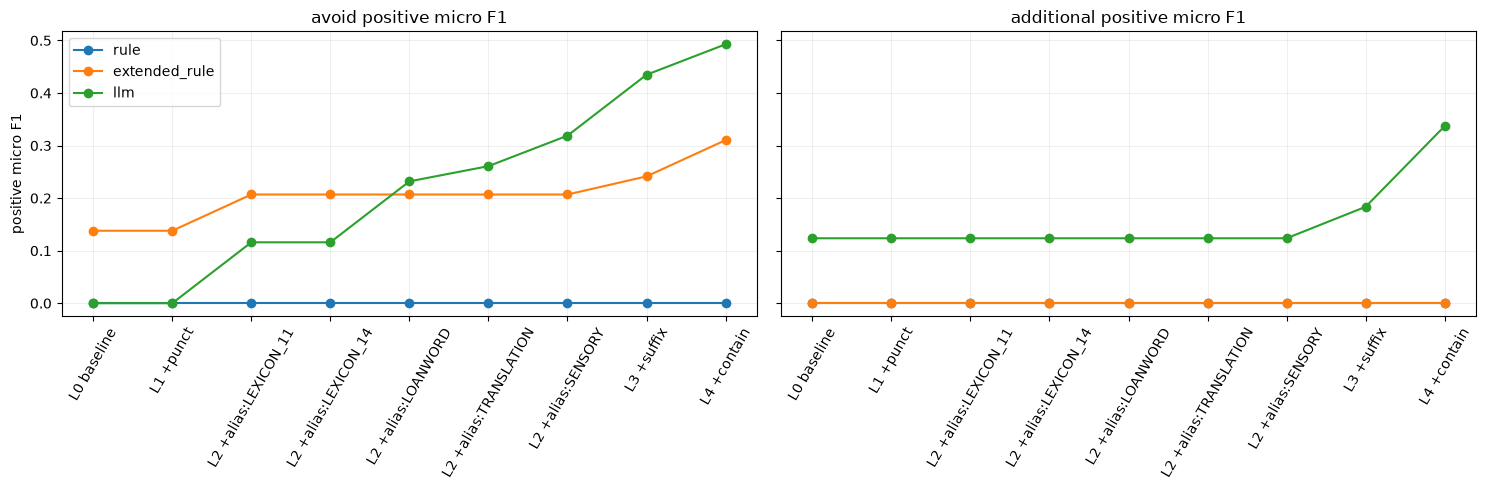

In [9]:
LAYER_STEPS = [
    ("L0 baseline", LAYERS_OFF, {}),
    ("L1 +punct", {**LAYERS_OFF, "L1_punct": True}, {}),
]
cumulative_alias = {}
for tier in ["LEXICON_11", "LEXICON_14", "LOANWORD", "TRANSLATION", "SENSORY"]:
    cumulative_alias = {**cumulative_alias, **ALIAS_BY_TIER.get(tier, {})}
    LAYER_STEPS.append((
        f"L2 +alias:{tier}",
        {**LAYERS_OFF, "L1_punct": True, "L2_alias": True},
        dict(cumulative_alias),
    ))
LAYER_STEPS.append((
    "L3 +suffix",
    {**LAYERS_OFF, "L1_punct": True, "L2_alias": True, "L3_suffix": True},
    dict(ALIAS),
))
LAYER_STEPS.append(("L4 +contain", dict(LAYERS_FULL), dict(ALIAS)))

ablation_rows = []
for label, layers, alias in LAYER_STEPS:
    for system in SYSTEMS:
        result = score_system(system, layers, alias)
        for field in ["avoid", "additional", "scent"]:
            ablation_rows.append({
                "step": label, "system": system, "field": field,
                "positive_micro_f1": result["positive"][field]["f1"],
                "eligible": result["positive"][field]["eligible_queries"],
                "overall_exact_match": result["exact_match_rate"],
            })

layer_contribution_df = pd.DataFrame(ablation_rows)
pivot = layer_contribution_df.pivot_table(
    index="step", columns=["field", "system"], values="positive_micro_f1", sort=False
)
display(pivot.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, field in zip(axes, ["avoid", "additional"]):
    subset = layer_contribution_df[layer_contribution_df["field"] == field]
    for system in SYSTEMS:
        rows = subset[subset["system"] == system]
        ax.plot(rows["step"], rows["positive_micro_f1"], marker="o", label=system)
    ax.set_title(f"{field} positive micro F1")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("positive micro F1")
axes[0].legend()
plt.tight_layout()
plt.show()

## 9. 관용도 민감도와 greedy 최적성

`MAX_EXCESS_TOKENS`를 바꿔가며 결과가 얼마나 움직이는지 본다. 하나의 숫자가 아니라 **구간**으로 보고하기 위한 근거다.
`무제한`은 참고로만 계산하고 채택하지 않는다 — Extended Rule의 과포획 span까지 득점시키기 때문이다.

greedy 1:1이 최대 매칭과 같은지도 브루트포스로 검증한다.

In [10]:
sweep_rows = []
for budget in [0, 1, 2, 3, 10**6]:
    label = "무제한" if budget > 100 else f"+{budget}"
    for system in SYSTEMS:
        result = score_system(system, LAYERS_FULL, ALIAS, max_excess=budget)
        frame = merged[system]
        for field, (gold_col, pred_col) in [
            ("avoid", ("gold_avoid", "pred_avoid")),
            ("additional", ("gold_additional_requirements", "pred_additional_requirements")),
        ]:
            gold_values, pred_values = frame[gold_col].tolist(), frame[pred_col].tolist()
            positive_mask = np.asarray([bool(dedupe_keys([canonical_key(v, LAYERS_FULL, ALIAS) for v in x]))
                                        for x in gold_values])
            coverage = evaluate_coverage(gold_values, pred_values, LAYERS_FULL, ALIAS, positive_mask, budget)
            sweep_rows.append({
                "max_excess": label, "system": system, "field": field,
                "f1_1to1": result["positive"][field]["f1"],
                "f1_coverage": coverage["f1"],
            })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.pivot_table(index="max_excess", columns=["field", "system"],
                             values="f1_1to1", sort=False).round(3))

# greedy 최적성 검증
greedy_suboptimal_queries = 0
for system in SYSTEMS:
    for row in merged[system].itertuples(index=False):
        for gold_col, pred_col in [("gold_avoid", "pred_avoid"),
                                   ("gold_additional_requirements", "pred_additional_requirements")]:
            tp, _, _, _, gold_keys, pred_keys = match_items(
                getattr(row, gold_col), getattr(row, pred_col), LAYERS_FULL, ALIAS)
            if tp != max_cardinality(gold_keys, pred_keys, LAYERS_FULL):
                greedy_suboptimal_queries += 1

print(f"greedy가 최대 매칭보다 작은 경우: {greedy_suboptimal_queries}건")
if greedy_suboptimal_queries:
    raise RuntimeError("greedy 매칭이 최적이 아닙니다 — 매칭 알고리즘을 재검토해야 합니다.")

field,avoid,additional,avoid,additional,avoid,additional
system,rule,rule,extended_rule,extended_rule,llm,llm
max_excess,,,,,,
+0,0.0,0.0,0.241,0.0,0.435,0.195
+1,0.0,0.0,0.310,0.0,0.493,0.337
+2,0.0,0.0,0.310,0.0,0.493,0.416
+3,0.0,0.0,0.345,0.0,0.493,0.506
무제한,0.0,0.0,0.448,0.0,0.493,0.622


greedy가 최대 매칭보다 작은 경우: 0건


## 10. 최종 재채점과 항목 단위 감사 추적

확정 규칙(모든 층 ON, `MAX_EXCESS_TOKENS = 1`)으로 세 시스템을 재채점하고,
어떤 gold 항목이 어떤 prediction 항목과 어떤 근거로 이어졌는지 전부 기록한다.

In [11]:
final_results = {system: score_system(system, LAYERS_FULL, ALIAS) for system in SYSTEMS}

detail_rows = []
for system in SYSTEMS:
    for row in merged[system].itertuples(index=False):
        for field, gold_col, pred_col in [
            ("avoid", "gold_avoid", "pred_avoid"),
            ("additional", "gold_additional_requirements", "pred_additional_requirements"),
            ("scent", "gold_scent_preference", "pred_scent_preference"),
        ]:
            gold_items, pred_items = getattr(row, gold_col), getattr(row, pred_col)
            tp, fp, fn, pairs, gold_keys, pred_keys = match_items(gold_items, pred_items, LAYERS_FULL, ALIAS)
            matched_gold = {g for g, _, _, _ in pairs}
            matched_pred = {p for _, p, _, _ in pairs}
            for gold_index, pred_index, tier, score in pairs:
                long_key, short_key = sorted([gold_keys[gold_index], pred_keys[pred_index]],
                                             key=lambda k: -len(k))
                detail_rows.append({
                    "query_id": row.query_id, "system": system, "field": field,
                    "outcome": "TP",
                    "gold_item": gold_items[gold_index] if gold_index < len(gold_items) else "",
                    "pred_item": pred_items[pred_index] if pred_index < len(pred_items) else "",
                    "gold_key": gold_keys[gold_index], "pred_key": pred_keys[pred_index],
                    "match_tier": "EXACT" if tier == 2 else "CONTAIN",
                    "excess_tokens": len(long_key.split()) - len(short_key.split()),
                    "resolution_status": "",
                })
            for gold_index, gold_key in enumerate(gold_keys):
                if gold_index in matched_gold:
                    continue
                detail_rows.append({
                    "query_id": row.query_id, "system": system, "field": field,
                    "outcome": "FN", "gold_item": gold_items[gold_index] if gold_index < len(gold_items) else "",
                    "pred_item": "", "gold_key": gold_key, "pred_key": "",
                    "match_tier": "", "excess_tokens": np.nan, "resolution_status": "",
                })
            for pred_index, pred_key in enumerate(pred_keys):
                if pred_index in matched_pred:
                    continue
                detail_rows.append({
                    "query_id": row.query_id, "system": system, "field": field,
                    "outcome": "FP", "gold_item": "",
                    "pred_item": pred_items[pred_index] if pred_index < len(pred_items) else "",
                    "gold_key": "", "pred_key": pred_key,
                    "match_tier": "", "excess_tokens": np.nan, "resolution_status": "",
                })

match_detail_df = pd.DataFrame(detail_rows)

comparison_rows = []
for field in ["avoid", "additional", "scent"]:
    row = {"field": field}
    for system in SYSTEMS:
        row[f"{system}_before"] = pd.read_csv(INPUT_PATHS[f"metrics_{system}"]).set_index("metric")["value"].get(
            f"positive_{field}_micro_f1", np.nan)
        row[f"{system}_after"] = final_results[system]["positive"][field]["f1"]
    comparison_rows.append(row)
display(pd.DataFrame(comparison_rows).round(3))
print(f"match_detail rows: {len(match_detail_df)}")

,field,rule_before,rule_after,extended_rule_before,extended_rule_after,llm_before,llm_after
0,avoid,0.000,0.000,0.138,0.310,0.000,0.493
1,additional,0.000,0.000,0.000,0.000,0.124,0.337
2,scent,0.459,0.459,0.531,0.531,0.642,0.716


match_detail rows: 1325


## 11. 잔여 실패 분류

규칙을 다 적용하고도 남은 FN이 무엇 때문인지 나눈다. 이게 **"규칙으로 더 할 수 있는 일"과 "모델이 실제로 못한 일"** 의 경계다.

- `EMPTY_PREDICTION` — 예측 자체가 비어 있음. **진짜 모델 실패**
- `CROSS_LINGUAL` — gold는 한국어인데 남은 예측이 영어. 번역 판단이라 표기 규칙으로 이을 수 없음. **사람 판정 대상**
- `PARAPHRASE_MISMATCH` — 둘 다 한국어인데 의역이라 포함 관계가 성립하지 않음. **사람 판정 대상**
- `ONE_TO_ONE_CAP` — 남은 예측이 없음. 하나의 예측이 여러 gold를 덮는데 1:1 제약에 걸린 경우

In [12]:
pred_count_by_key = {
    (system, row.query_id, field): len(getattr(row, pred_col))
    for system in SYSTEMS
    for row in merged[system].itertuples(index=False)
    for field, pred_col in [("avoid", "pred_avoid"),
                            ("additional", "pred_additional_requirements"),
                            ("scent", "pred_scent_preference")]
}
# 매칭되지 못하고 남은 prediction 항목 (FP) — gold를 못 이은 이유를 가리는 재료
leftover_pred = (
    match_detail_df[match_detail_df["outcome"] == "FP"]
    .groupby(["system", "query_id", "field"])["pred_key"].apply(list).to_dict()
)

HANGUL_PATTERN = re.compile(r"[가-힣]")
LATIN_PATTERN = re.compile(r"[a-z]")


def classify_fn(row):
    if row["outcome"] != "FN":
        return ""
    key = (row["system"], row["query_id"], row["field"])
    if pred_count_by_key.get(key, 0) == 0:
        return "EMPTY_PREDICTION"
    leftovers = leftover_pred.get(key, [])
    if not leftovers:
        return "ONE_TO_ONE_CAP"
    gold_is_korean = bool(HANGUL_PATTERN.search(row["gold_key"]))
    if gold_is_korean and any(
        LATIN_PATTERN.search(k) and not HANGUL_PATTERN.search(k) for k in leftovers
    ):
        return "CROSS_LINGUAL"
    return "PARAPHRASE_MISMATCH"


match_detail_df["resolution_status"] = match_detail_df.apply(classify_fn, axis=1)

residual = match_detail_df[match_detail_df["outcome"] == "FN"]
display(residual.pivot_table(index="resolution_status", columns=["field", "system"],
                             values="query_id", aggfunc="count", fill_value=0))

llm_residual = residual[residual["system"] == "llm"]
for status in ["CROSS_LINGUAL", "PARAPHRASE_MISMATCH"]:
    subset = llm_residual[llm_residual["resolution_status"] == status]
    display(Markdown(f"### LLM {status} — 사람 판정으로 보낼 항목 ({len(subset)}건)"))
    rows = []
    for row in subset.head(15).itertuples(index=False):
        rows.append({
            "query_id": row.query_id, "field": row.field, "gold_item": row.gold_item,
            "남은 예측": " / ".join(leftover_pred.get((row.system, row.query_id, row.field), []))[:60],
        })
    display(pd.DataFrame(rows))

field                  additional                   avoid                  scent         
system              extended_rule  llm rule extended_rule llm rule extended_rule llm rule
resolution_status                                                                        
CROSS_LINGUAL                   0    9    0             0  10    0             0   0    0
EMPTY_PREDICTION              272    4  272            19  11   40            28  14   30
ONE_TO_ONE_CAP                  0   14    0             1   0    0             1   0    2
PARAPHRASE_MISMATCH             0  155    0            11   2    0             0   3    0

### LLM CROSS_LINGUAL — 사람 판정으로 보낼 항목 (19건)

,query_id,field,gold_item,남은 예측
0,UQ0005,avoid,너무 단,too sweet
1,UQ0011,avoid,절 냄새,too strong only religious temple like scent
2,UQ0022,avoid,조말론 블랙베리,blackberry jo malone blackberry
3,UQ0054,avoid,너무 음식같은 느낌,too food like
4,UQ0084,additional,데일리 향수,daily
5,UQ0086,additional,데일리로 쓰기 좋은,daily use
6,UQ0101,additional,달달한 꽃,sweet / floral
7,UQ0116,additional,달달하지만,sweet / 너무 느끼하지 않은
8,UQ0149,avoid,남자 스킨 냄새,male skin scent
9,UQ0150,avoid,중후한,heavy and mature


### LLM PARAPHRASE_MISMATCH — 사람 판정으로 보낼 항목 (160건)

,query_id,field,gold_item,남은 예측
0,UQ0003,additional,구색 갖추려고,그냥 구색 갖추려고 사는 목적
1,UQ0007,additional,30대 초반,30대 초반 남자가 쓰기 좋은
2,UQ0010,additional,공주,케이크 같은 / 너무 느끼하지 않은 / 딱 맡았을 때 공주처럼 느껴지는
3,UQ0011,scent,Trees,woody
4,UQ0013,additional,머리 너무 안 아팠으면,머리 안 아프게 두통이 없었으면 좋겠음
5,UQ0014,additional,잘 모르는데 혹시 추천,향수를 잘 모름 / 추천 요청
6,UQ0018,additional,여친한테 점수 딸만한,여자친구에게 점수 딸만한 향기 호감 목적
7,UQ0019,additional,옷에 향수,옷에 향수 뿌리고 싶음
8,UQ0020,additional,분사 적당히 되는 거,향수 분사량이 적당한 / 입자가 너무 작은 건 싫음
9,UQ0021,additional,이솝 테싯 퍼퓸,aesop tetsit perfume를 자주 사용하며 체향에 잘 맞는 것 같음 / 비슷한데 다른 향 ...


## 12. 저장

In [13]:
metric_rows = []


def add_metric(metric, value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return
    metric_rows.append({"metric": metric, "value": float(value)})


for system in SYSTEMS:
    for metric, value in metric_dict(final_results[system]).items():
        add_metric(f"{system}_{metric}", value)

add_metric("max_excess_tokens", MAX_EXCESS_TOKENS)
add_metric("min_match_chars", MIN_MATCH_CHARS)
add_metric("alias_rows_total", len(alias_table_df))
add_metric("alias_rows_sensory", int((alias_table_df["evidence_tier"] == "SENSORY").sum()))
add_metric("normalizer_divergent_strings", normalizer_divergent_strings)
add_metric("greedy_suboptimal_queries", greedy_suboptimal_queries)
add_metric("baseline_reproduction_mismatches", baseline_reproduction_mismatches)
add_metric("baseline_metrics_checked", len(gate_df))

metrics_df = pd.DataFrame(metric_rows)
if metrics_df["metric"].duplicated().any():
    raise ValueError(f"중복 metric: {metrics_df.loc[metrics_df['metric'].duplicated(), 'metric'].tolist()}")

before_after = pd.DataFrame(comparison_rows).round(4)


def markdown_table(frame):
    # tabulate 의존성을 추가하지 않으려고 직접 만든다.
    header = "| " + " | ".join(frame.columns) + " |"
    divider = "|" + "|".join(["---"] * len(frame.columns)) + "|"
    body = [
        "| " + " | ".join("" if pd.isna(v) else f"{v:.4f}" if isinstance(v, float) else str(v)
                          for v in row) + " |"
        for row in frame.itertuples(index=False)
    ]
    return "\n".join([header, divider, *body])


summary_text = f"""# Stage 1 Rescoring Rule v2

## 질문

Stage 1의 `avoid` micro-F1 0.000과 `additional` 0.118 중 얼마가 채점 규칙의 문제인가.

## 방법

기존 Prediction을 그대로 사용하고 채점 규칙만 층으로 분해했다. **API 호출 없음. 모델 재실행 없음.**
Notebook 13/14/15/16과 Golden Set은 수정하지 않았다.

- 규칙 버전: `{RULE_VERSION}`
- `MAX_EXCESS_TOKENS = {MAX_EXCESS_TOKENS}` (사전 등록)
- 별칭 항목 {len(alias_table_df)}개 (그중 검증 불가한 `SENSORY` tier {int((alias_table_df["evidence_tier"] == "SENSORY").sum())}개)

## 재현 게이트

모든 층을 끈 상태에서 published 지표 **{len(gate_df)}개를 대조해 불일치 {baseline_reproduction_mismatches}개**.
새 채점기는 기존 채점기의 상위 집합이다.

## 정규화기 대조

13/14번은 NFKC를 적용하고 15번은 하지 않는다. 라벨 문자열 {len(label_strings)}개 중
**차이를 만드는 것은 {normalizer_divergent_strings}개**였다.

## Positive-only micro F1 (전 → 후)

{markdown_table(before_after)}

## 매칭 알고리즘

greedy 1:1 매칭이 최대 매칭과 다른 경우 **{greedy_suboptimal_queries}건**.

## 한계

- 이 숫자는 채점 규칙 변경분이다. **모델 성능이 좋아진 것이 아니다.**
- `SENSORY` tier는 Fragrantica 어휘로 검증할 수 없다. 기여도를 별도 행으로 보고했다.
- 1:1 매칭은 하나의 prediction이 여러 gold를 덮는 경우 recall을 구조적으로 제한한다.
- `rule`과 `extended_rule`은 `additional`을 200/200 빈 값으로 예측하므로 어떤 규칙에서도 0이다.
- 별칭표는 Golden Set 200개를 보고 골랐다. Unseen 평가에는 사용할 수 없다.
"""

write_output(OUTPUT_PATHS["metrics"], lambda p: metrics_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["layers"], lambda p: layer_contribution_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["detail"], lambda p: match_detail_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["alias"], lambda p: alias_table_df.to_csv(p, index=False, encoding="utf-8-sig"))
write_output(OUTPUT_PATHS["summary"], lambda p: p.write_text(summary_text, encoding="utf-8"))

if not REPORT_ONLY:
    reread = pd.read_csv(OUTPUT_PATHS["metrics"])
    if reread.columns.tolist() != ["metric", "value"] or reread["metric"].duplicated().any():
        raise ValueError("metrics 스키마 검증 실패")
    detail_tp = int((pd.read_csv(OUTPUT_PATHS["detail"])["outcome"] == "TP").sum())
    metric_tp = sum(final_results[s]["all"][f]["tp"] for s in SYSTEMS for f in ["avoid", "additional", "scent"])
    if detail_tp != metric_tp:
        raise ValueError(f"match_detail TP({detail_tp}) != metrics TP({metric_tp})")
    print(f"검증 통과 — metrics {len(reread)}행, detail TP {detail_tp}건")

저장: 25_stage1_rescoring_metrics.csv
저장: 25_stage1_rescoring_layer_contribution.csv
저장: 25_stage1_rescoring_match_detail.csv
저장: 25_stage1_scoring_alias_v1.csv
저장: 25_stage1_rescoring_summary.md
검증 통과 — metrics 182행, detail TP 176건


## 13. 가드 검증

입력과 보호 디렉터리가 실행 전후로 동일한지 확인한다.

In [14]:
input_hashes_after = {label: sha256_file(path) for label, path in INPUT_PATHS.items()}
changed_inputs = [k for k in input_hashes_before if input_hashes_before[k] != input_hashes_after[k]]
if changed_inputs:
    raise RuntimeError(f"입력이 변경됐습니다: {changed_inputs}")

frozen_after = {str(root): directory_fingerprint(root) for root in FROZEN_DIRS}
for root in frozen_before:
    if frozen_before[root] != frozen_after[root]:
        added = set(frozen_after[root]) - set(frozen_before[root])
        removed = set(frozen_before[root]) - set(frozen_after[root])
        modified = {k for k in set(frozen_before[root]) & set(frozen_after[root])
                    if frozen_before[root][k] != frozen_after[root][k]}
        raise RuntimeError(f"보호 디렉터리 변경 {root}: 추가={added} 삭제={removed} 수정={modified}")

candidates_path = OUTPUT_DIR / "16_golden_set_quality_audit_candidates.csv"
candidates_df = pd.read_csv(candidates_path)
if candidates_df[["manual_decision", "manual_issue_type", "manual_comment"]].notna().any().any():
    print("주의: 16번 candidates 원본에 수동 판정이 들어 있습니다. 복사본에 기입해야 합니다.")

print("입력 해시 동일 / 보호 디렉터리 동일")
print("생성한 출력:")
for label, path in OUTPUT_PATHS.items():
    print(f"  {label}: {path.name}{'' if path.is_file() else '  (REPORT_ONLY로 미생성)'}")

입력 해시 동일 / 보호 디렉터리 동일


생성한 출력:
  metrics: 25_stage1_rescoring_metrics.csv
  layers: 25_stage1_rescoring_layer_contribution.csv
  detail: 25_stage1_rescoring_match_detail.csv
  alias: 25_stage1_scoring_alias_v1.csv
  summary: 25_stage1_rescoring_summary.md
